# Volatility Regime Analysis

Financial markets often alternate between calm and turbulent periods.

In this notebook, we analyze volatility regimes and identify transitions between low-volatility and high-volatility market states.

Objectives:
1. Detect volatility regimes
2. Analyze periods of market stress
3. Compare regime persistence across assets
4. Visualize state transitions# Volatility Regime Analysis



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

btc["rolling_vol"] = (
    btc["log_return"]
    .rolling(30)
    .std()
)

In [4]:
threshold = sp500["rolling_vol"].median()

sp500["regime"] = np.where(
    sp500["rolling_vol"] > threshold,
    "High Volatility",
    "Low Volatility"
)

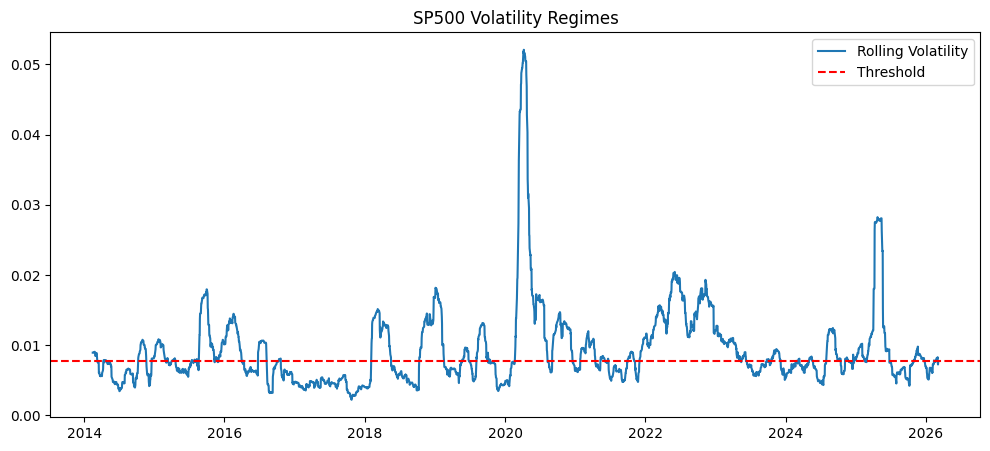

In [5]:
plt.figure(figsize=(12,5))

plt.plot(sp500["rolling_vol"], label="Rolling Volatility")

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.legend()

plt.title("SP500 Volatility Regimes")

plt.show()

In [6]:
sp500["regime"].value_counts()

regime
Low Volatility     1545
High Volatility    1516
Name: count, dtype: int64

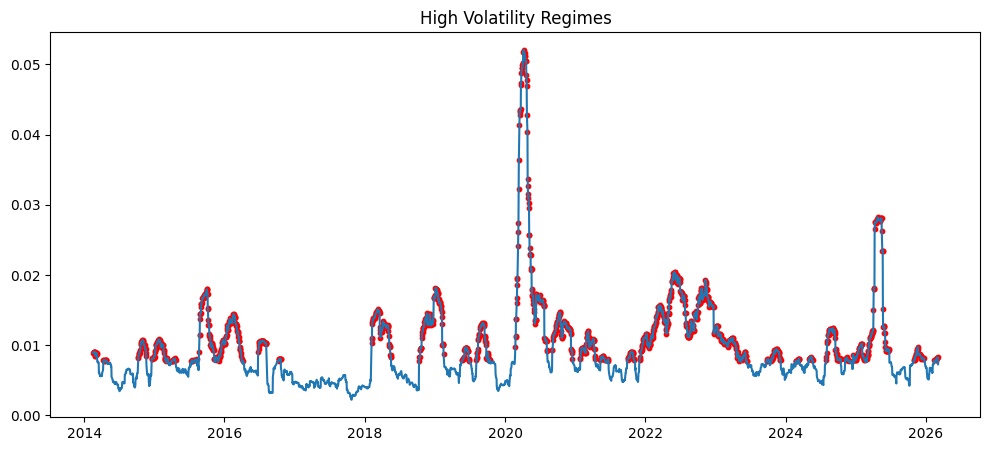

In [7]:
high_vol = sp500[
    sp500["regime"] == "High Volatility"
]

plt.figure(figsize=(12,5))

plt.plot(sp500.index, sp500["rolling_vol"])

plt.scatter(
    high_vol.index,
    high_vol["rolling_vol"],
    color="red",
    s=10
)

plt.title("High Volatility Regimes")

plt.show()

## Regime Interpretation

The market alternates between calm and turbulent volatility states.

High-volatility regimes correspond to periods of uncertainty, market stress, and increased downside risk.

BTC typically exhibits more frequent and persistent high-volatility regimes compared to SP500.